In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt

# Normalization techniques

In [2]:
# define transformations for the data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # mean and standard deviation for MNIST
])

# download the complete MNIST data set
full_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# split the data set into training and validation
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# create a test data set
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# determine the batch size
batch_size = 64

# create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")
print(f"Number of batches in train_loader: {len(train_loader)}")

Train set size: 48000
Validation set size: 12000
Test set size: 10000
Number of batches in train_loader: 750


In [3]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 10)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

In [4]:
# no regularization

model = Net()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

num_epochs = 20

train_losses = []
train_accs = []

val_losses = []
val_accs = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data.view(data.size(0), -1))
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = output.max(1)
        train_total += target.size(0)
        train_correct += predicted.eq(target).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = 100. * train_correct / train_total
    
    train_losses.append(train_loss)
    train_accs.append(train_accuracy)

    # validation step
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for data, target in val_loader:
            output = model(data.view(data.size(0), -1))
            loss = criterion(output, target)
            val_loss += loss.item()
            _, predicted = output.max(1)
            val_total += target.size(0)
            val_correct += predicted.eq(target).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = 100. * val_correct / val_total
    
    val_losses.append(val_loss)
    val_accs.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}]')
    print(f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%')
    print(f'Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%')
    print('-' * 50)

Epoch [1/20]
Train Loss: 0.2208, Train Accuracy: 93.26%
Val Loss: 0.1311, Val Accuracy: 96.04%
--------------------------------------------------
Epoch [2/20]
Train Loss: 0.0912, Train Accuracy: 97.10%
Val Loss: 0.1005, Val Accuracy: 96.92%
--------------------------------------------------
Epoch [3/20]
Train Loss: 0.0674, Train Accuracy: 97.90%
Val Loss: 0.0952, Val Accuracy: 97.18%
--------------------------------------------------
Epoch [4/20]
Train Loss: 0.0519, Train Accuracy: 98.34%
Val Loss: 0.0926, Val Accuracy: 97.49%
--------------------------------------------------
Epoch [5/20]
Train Loss: 0.0380, Train Accuracy: 98.74%
Val Loss: 0.1066, Val Accuracy: 97.28%
--------------------------------------------------
Epoch [6/20]
Train Loss: 0.0353, Train Accuracy: 98.85%
Val Loss: 0.1069, Val Accuracy: 97.34%
--------------------------------------------------
Epoch [7/20]
Train Loss: 0.0306, Train Accuracy: 99.01%
Val Loss: 0.1073, Val Accuracy: 97.46%
-----------------------------

In [5]:
def visualize_training_history(train_losses, train_accs, val_losses, val_accs):
    epochs = range(1, len(train_losses) + 1)

    plt.figure(figsize=(12, 5))

    # loss plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, 'b-', label='Train Loss')
    plt.plot(epochs, val_losses, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs, train_accs, 'b-', label='Train Accuracy')
    plt.plot(epochs, val_accs, 'r-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

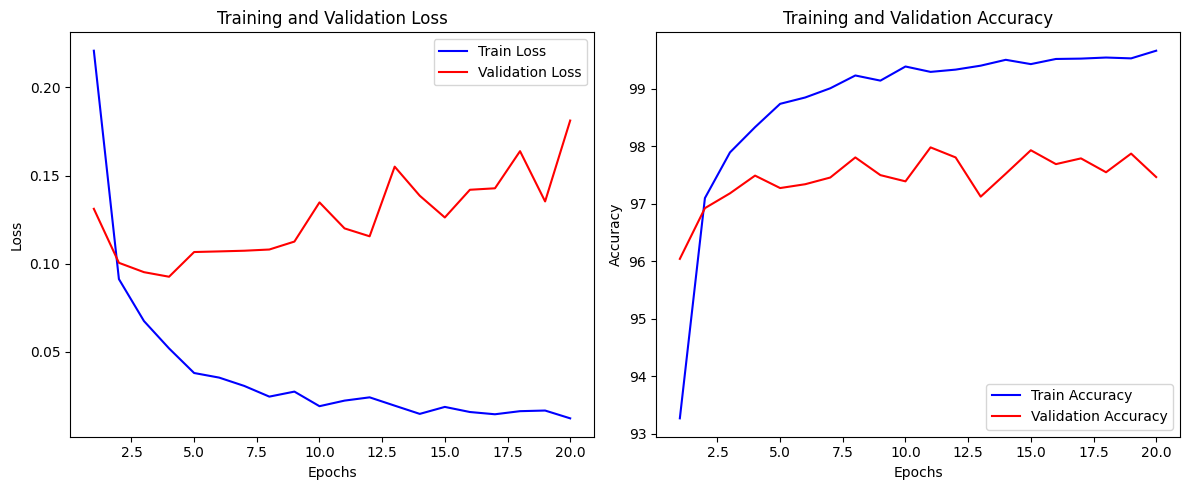

In [6]:
visualize_training_history(train_losses, train_accs, val_losses, val_accs)

Epoch [1/20]
Train Loss: 0.2265, Train Accuracy: 92.94%
Val Loss: 0.1217, Val Accuracy: 96.22%
--------------------------------------------------
Epoch [2/20]
Train Loss: 0.1145, Train Accuracy: 96.52%
Val Loss: 0.1110, Val Accuracy: 96.59%
--------------------------------------------------
Epoch [3/20]
Train Loss: 0.0956, Train Accuracy: 97.04%
Val Loss: 0.1081, Val Accuracy: 96.62%
--------------------------------------------------
Epoch [4/20]
Train Loss: 0.0834, Train Accuracy: 97.46%
Val Loss: 0.1148, Val Accuracy: 96.53%
--------------------------------------------------
Epoch [5/20]
Train Loss: 0.0721, Train Accuracy: 97.77%
Val Loss: 0.1059, Val Accuracy: 96.95%
--------------------------------------------------
Epoch [6/20]
Train Loss: 0.0702, Train Accuracy: 97.80%
Val Loss: 0.0901, Val Accuracy: 97.25%
--------------------------------------------------
Epoch [7/20]
Train Loss: 0.0646, Train Accuracy: 98.02%
Val Loss: 0.1107, Val Accuracy: 96.62%
-----------------------------

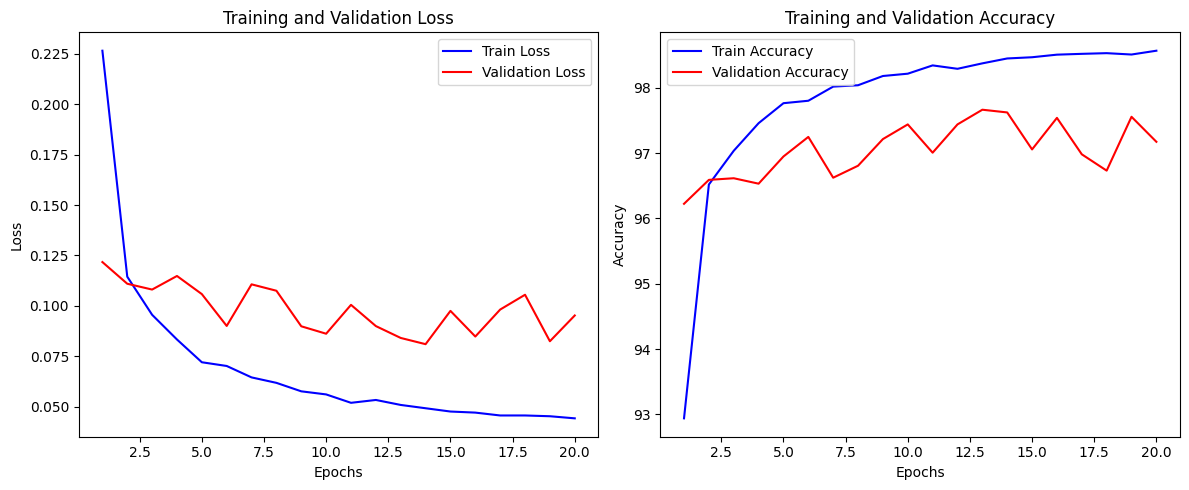

In [7]:
# L2 regularization

model = Net()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), weight_decay=1e-3)

num_epochs = 20

train_losses = []
train_accs = []

val_losses = []
val_accs = []

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data.view(data.size(0), -1))
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, predicted = output.max(1)
        train_total += target.size(0)
        train_correct += predicted.eq(target).sum().item()

    train_loss /= len(train_loader)
    train_accuracy = 100. * train_correct / train_total
    
    train_losses.append(train_loss)
    train_accs.append(train_accuracy)

    # validation step
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for data, target in val_loader:
            output = model(data.view(data.size(0), -1))
            loss = criterion(output, target)
            val_loss += loss.item()
            _, predicted = output.max(1)
            val_total += target.size(0)
            val_correct += predicted.eq(target).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = 100. * val_correct / val_total
    
    val_losses.append(val_loss)
    val_accs.append(val_accuracy)

    print(f'Epoch [{epoch+1}/{num_epochs}]')
    print(f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%')
    print(f'Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%')
    print('-' * 50)
    
visualize_training_history(train_losses, train_accs, val_losses, val_accs)

In [8]:
# early stopping

model = Net()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())
best_val_loss = float('inf')
patience = 2
counter = 0

train_losses = []
train_accs = []
val_losses = []
val_accs = []

for epoch in range(20):
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data.view(data.size(0), -1))
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = output.max(1)
        train_total += target.size(0)
        train_correct += predicted.eq(target).sum().item()
    
    train_loss /= len(train_loader)
    train_acc = 100. * train_correct / train_total
    
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for data, target in val_loader:
            output = model(data.view(data.size(0), -1))
            val_loss += criterion(output, target).item()
            _, predicted = output.max(1)
            val_total += target.size(0)
            val_correct += predicted.eq(target).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = 100. * val_correct / val_total
    
    # save results
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f'Epoch {epoch}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

Epoch 0: Train Loss: 0.2224, Train Acc: 93.15%, Val Loss: 0.1267, Val Acc: 96.25%
Epoch 1: Train Loss: 0.0955, Train Acc: 97.03%, Val Loss: 0.0855, Val Acc: 97.37%
Epoch 2: Train Loss: 0.0637, Train Acc: 98.00%, Val Loss: 0.0887, Val Acc: 97.38%
Epoch 3: Train Loss: 0.0502, Train Acc: 98.43%, Val Loss: 0.0969, Val Acc: 97.31%
Early stopping at epoch 3


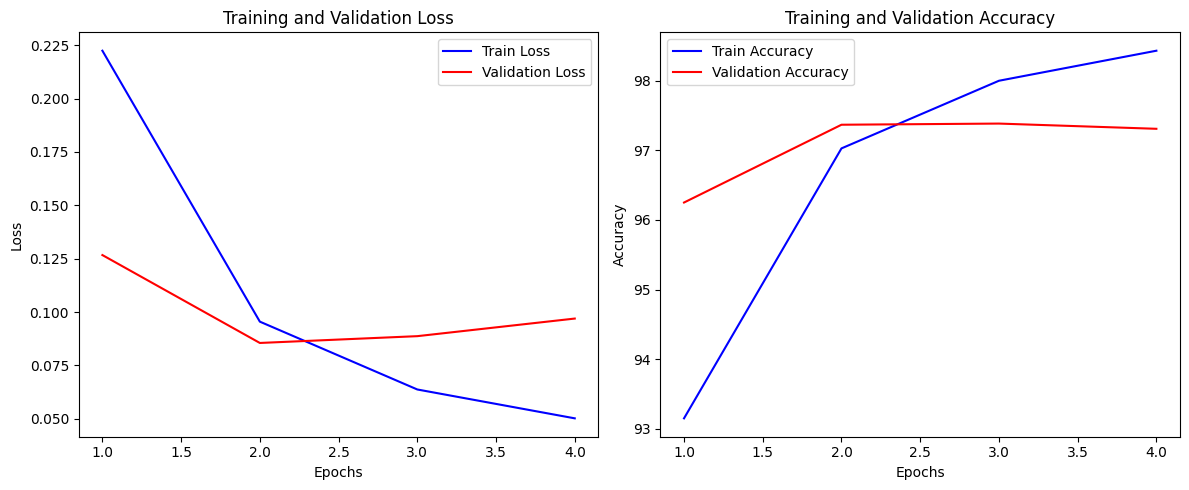

In [9]:
visualize_training_history(train_losses, train_accs, val_losses, val_accs)

In [10]:
class NetWithDropout(nn.Module):
    def __init__(self):
        super(NetWithDropout, self).__init__()
        self.fc1 = nn.Linear(784, 512)
        self.dropout1 = nn.Dropout(0.2)
        self.fc2 = nn.Linear(512, 512)
        self.dropout2 = nn.Dropout(0.2)
        self.fc3 = nn.Linear(512, 10)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        return self.fc3(x)

In [11]:
# dropout

model = NetWithDropout()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

train_losses = []
train_accs = []
val_losses = []
val_accs = []

for epoch in range(20):
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data.view(data.size(0), -1))
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = output.max(1)
        train_total += target.size(0)
        train_correct += predicted.eq(target).sum().item()
    
    train_loss /= len(train_loader)
    train_acc = 100. * train_correct / train_total
    
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for data, target in val_loader:
            output = model(data.view(data.size(0), -1))
            val_loss += criterion(output, target).item()
            _, predicted = output.max(1)
            val_total += target.size(0)
            val_correct += predicted.eq(target).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = 100. * val_correct / val_total
    
    # save results
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f'Epoch {epoch}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

Epoch 0: Train Loss: 0.2484, Train Acc: 92.36%, Val Loss: 0.1335, Val Acc: 95.87%
Epoch 1: Train Loss: 0.1184, Train Acc: 96.37%, Val Loss: 0.1101, Val Acc: 96.57%
Epoch 2: Train Loss: 0.0941, Train Acc: 97.10%, Val Loss: 0.0902, Val Acc: 97.37%
Epoch 3: Train Loss: 0.0762, Train Acc: 97.63%, Val Loss: 0.0988, Val Acc: 97.10%
Epoch 4: Train Loss: 0.0687, Train Acc: 97.83%, Val Loss: 0.0978, Val Acc: 97.29%
Epoch 5: Train Loss: 0.0588, Train Acc: 98.19%, Val Loss: 0.0845, Val Acc: 97.78%
Epoch 6: Train Loss: 0.0521, Train Acc: 98.31%, Val Loss: 0.0907, Val Acc: 97.67%
Epoch 7: Train Loss: 0.0483, Train Acc: 98.53%, Val Loss: 0.0973, Val Acc: 97.76%
Epoch 8: Train Loss: 0.0484, Train Acc: 98.47%, Val Loss: 0.0988, Val Acc: 97.84%
Epoch 9: Train Loss: 0.0459, Train Acc: 98.54%, Val Loss: 0.1110, Val Acc: 97.44%
Epoch 10: Train Loss: 0.0430, Train Acc: 98.67%, Val Loss: 0.0928, Val Acc: 97.90%
Epoch 11: Train Loss: 0.0384, Train Acc: 98.84%, Val Loss: 0.0996, Val Acc: 97.74%
Epoch 12: Trai

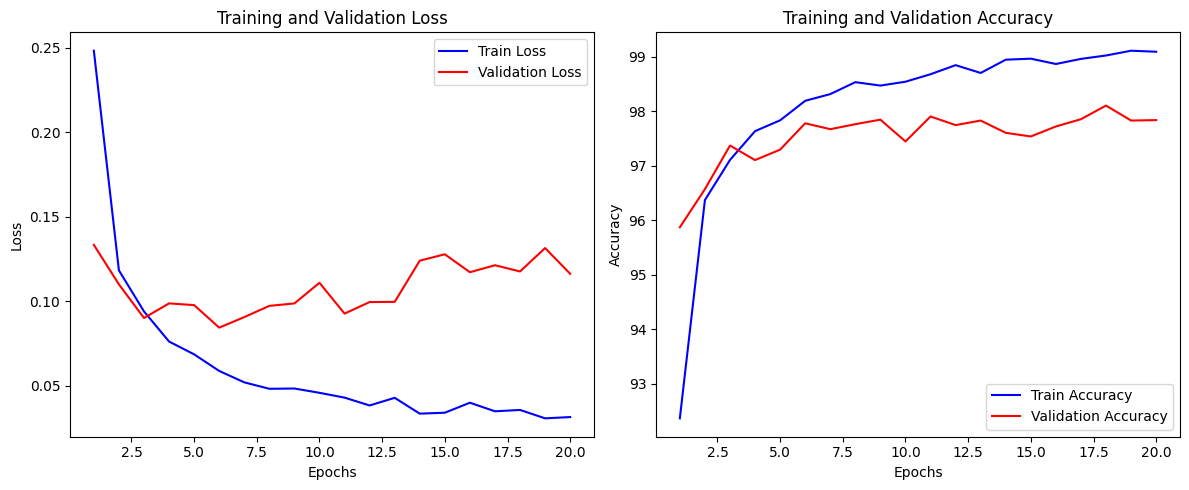

In [12]:
visualize_training_history(train_losses, train_accs, val_losses, val_accs)

In [13]:
class NetWithBN(nn.Module):
    def __init__(self):
        super(NetWithBN, self).__init__()
        self.fc1 = nn.Linear(784, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 256)
        self.bn2 = nn.BatchNorm1d(256)
        self.fc3 = nn.Linear(256, 10)

    def forward(self, x):
        x = torch.relu(self.bn1(self.fc1(x)))
        x = torch.relu(self.bn2(self.fc2(x)))
        return self.fc3(x)

Epoch 0: Train Loss: 0.2104, Train Acc: 93.83%, Val Loss: 0.1098, Val Acc: 96.57%
Epoch 1: Train Loss: 0.0905, Train Acc: 97.14%, Val Loss: 0.0921, Val Acc: 97.03%
Epoch 2: Train Loss: 0.0600, Train Acc: 98.02%, Val Loss: 0.0838, Val Acc: 97.26%
Epoch 3: Train Loss: 0.0470, Train Acc: 98.44%, Val Loss: 0.0787, Val Acc: 97.78%
Epoch 4: Train Loss: 0.0370, Train Acc: 98.75%, Val Loss: 0.0872, Val Acc: 97.31%
Epoch 5: Train Loss: 0.0325, Train Acc: 98.96%, Val Loss: 0.0817, Val Acc: 97.76%
Epoch 6: Train Loss: 0.0237, Train Acc: 99.18%, Val Loss: 0.0803, Val Acc: 97.78%
Epoch 7: Train Loss: 0.0227, Train Acc: 99.26%, Val Loss: 0.0867, Val Acc: 97.70%
Epoch 8: Train Loss: 0.0228, Train Acc: 99.23%, Val Loss: 0.0782, Val Acc: 98.01%
Epoch 9: Train Loss: 0.0180, Train Acc: 99.39%, Val Loss: 0.0795, Val Acc: 98.03%
Epoch 10: Train Loss: 0.0169, Train Acc: 99.45%, Val Loss: 0.0752, Val Acc: 98.10%
Epoch 11: Train Loss: 0.0131, Train Acc: 99.56%, Val Loss: 0.0765, Val Acc: 98.10%
Epoch 12: Trai

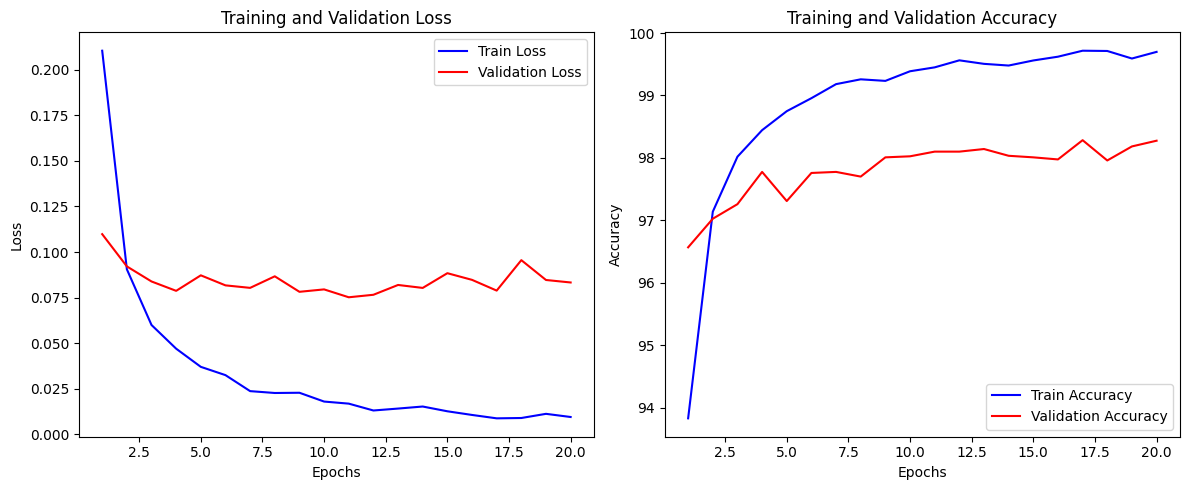

In [14]:
# BN

model = NetWithBN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

train_losses = []
train_accs = []
val_losses = []
val_accs = []

for epoch in range(20):
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0
    for batch_idx, (data, target) in enumerate(train_loader):
        optimizer.zero_grad()
        output = model(data.view(data.size(0), -1))
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        _, predicted = output.max(1)
        train_total += target.size(0)
        train_correct += predicted.eq(target).sum().item()
    
    train_loss /= len(train_loader)
    train_acc = 100. * train_correct / train_total
    
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for data, target in val_loader:
            output = model(data.view(data.size(0), -1))
            val_loss += criterion(output, target).item()
            _, predicted = output.max(1)
            val_total += target.size(0)
            val_correct += predicted.eq(target).sum().item()
    
    val_loss /= len(val_loader)
    val_acc = 100. * val_correct / val_total
    
    # save results
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    
    print(f'Epoch {epoch}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, '
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
    
    
visualize_training_history(train_losses, train_accs, val_losses, val_accs)

# Hyperparameter optimization

In [15]:
import optuna

In [16]:
class Net(nn.Module):
    def __init__(self, dropout_rate, use_batchnorm):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 512)
        self.fc3 = nn.Linear(512, 10)
        self.dropout = nn.Dropout(dropout_rate)
        self.use_batchnorm = use_batchnorm
        if use_batchnorm:
            self.bn1 = nn.BatchNorm1d(512)
            self.bn2 = nn.BatchNorm1d(512)

    def forward(self, x):
        x = x.view(-1, 784)
        x = self.fc1(x)
        if self.use_batchnorm:
            x = self.bn1(x)
        x = torch.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        if self.use_batchnorm:
            x = self.bn2(x)
        x = torch.relu(x)
        x = self.dropout(x)
        return self.fc3(x)

In [17]:
def objective(trial):
    # determine hyperparameters for optimization
    lr = trial.suggest_float('lr', 1e-5, 1e-1, log=True)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    use_batchnorm = trial.suggest_categorical('use_batchnorm', [True, False])
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128, 256])
    
    # create a model with selected hyperparameters
    model = Net(dropout_rate, use_batchnorm)
    
    # training settings
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    
    # model training
    model.train()
    for epoch in range(10):  # let's limit it to 10 epochs for speed
        for batch_idx, (data, target) in enumerate(train_loader):
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
        
        # Early stopping
        if epoch > 2 and loss.item() > prev_loss:
            break
        prev_loss = loss.item()
    
    # model evaluation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in DataLoader(test_dataset, batch_size=1000):
            output = model(data)
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    accuracy = correct / total
    return accuracy

In [18]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

print('Number of finished trials:', len(study.trials))
print('Best trial:')
trial = study.best_trial
print('  Value: ', trial.value)
print('  Params: ')
for key, value in trial.params.items():
    print('    {}: {}'.format(key, value))

[I 2025-05-24 15:18:09,835] A new study created in memory with name: no-name-cf296b3c-4da0-49d0-ba34-3b309f33b5db
[I 2025-05-24 15:19:13,730] Trial 0 finished with value: 0.9795 and parameters: {'lr': 0.0006717486227829821, 'dropout_rate': 0.2181096862362137, 'use_batchnorm': True, 'batch_size': 32}. Best is trial 0 with value: 0.9795.
[I 2025-05-24 15:19:30,581] Trial 1 finished with value: 0.9767 and parameters: {'lr': 0.0004330171460849385, 'dropout_rate': 0.3551251333524289, 'use_batchnorm': False, 'batch_size': 128}. Best is trial 0 with value: 0.9795.
[I 2025-05-24 15:19:47,195] Trial 2 finished with value: 0.9781 and parameters: {'lr': 0.0003060487631845681, 'dropout_rate': 0.3257342106986679, 'use_batchnorm': True, 'batch_size': 64}. Best is trial 0 with value: 0.9795.
[I 2025-05-24 15:21:20,196] Trial 3 finished with value: 0.9452 and parameters: {'lr': 0.004392103195606789, 'dropout_rate': 0.2834278968599725, 'use_batchnorm': False, 'batch_size': 32}. Best is trial 0 with val

Number of finished trials: 100
Best trial:
  Value:  0.9837
  Params: 
    lr: 0.0009461574698684913
    dropout_rate: 0.16551107630303655
    use_batchnorm: True
    batch_size: 32


/tmp/ipykernel_215961/3302522744.py:3: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


<Figure size 1000x600 with 0 Axes>

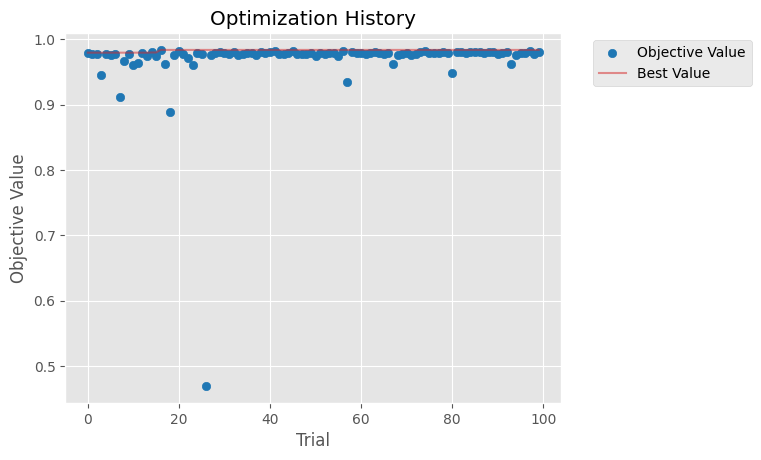

In [19]:
# 1. Optimization history plot
plt.figure(figsize=(10, 6))
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title("Optimization History")
plt.show()

/tmp/ipykernel_215961/2854606975.py:3: ExperimentalWarning: plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


<Figure size 1000x600 with 0 Axes>

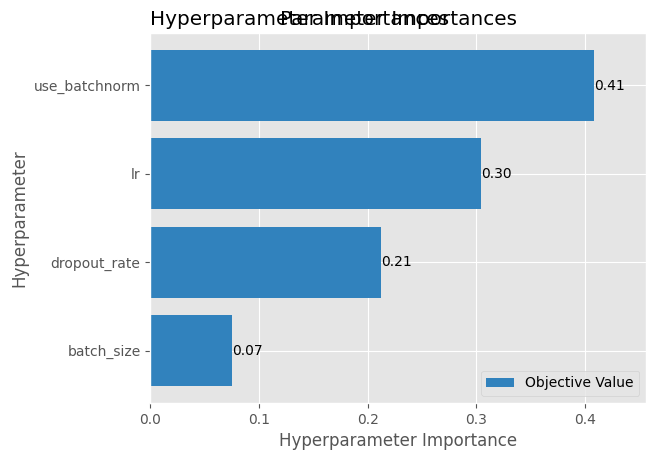

In [20]:
# 2. Parameter importance plot
plt.figure(figsize=(10, 6))
optuna.visualization.matplotlib.plot_param_importances(study)
plt.title("Parameter Importances")
plt.show()

/tmp/ipykernel_215961/4239929850.py:3: ExperimentalWarning: plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_parallel_coordinate(study)


<Figure size 1000x600 with 0 Axes>

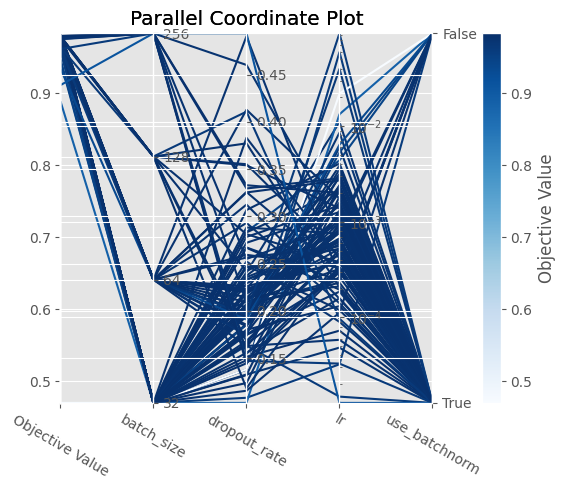

In [21]:
# 3. Parameters interaction plot
plt.figure(figsize=(10, 6))
optuna.visualization.matplotlib.plot_parallel_coordinate(study)
plt.title("Parallel Coordinate Plot")
plt.show()

/tmp/ipykernel_215961/2928570007.py:3: ExperimentalWarning: plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_slice(study)


<Figure size 1000x600 with 0 Axes>

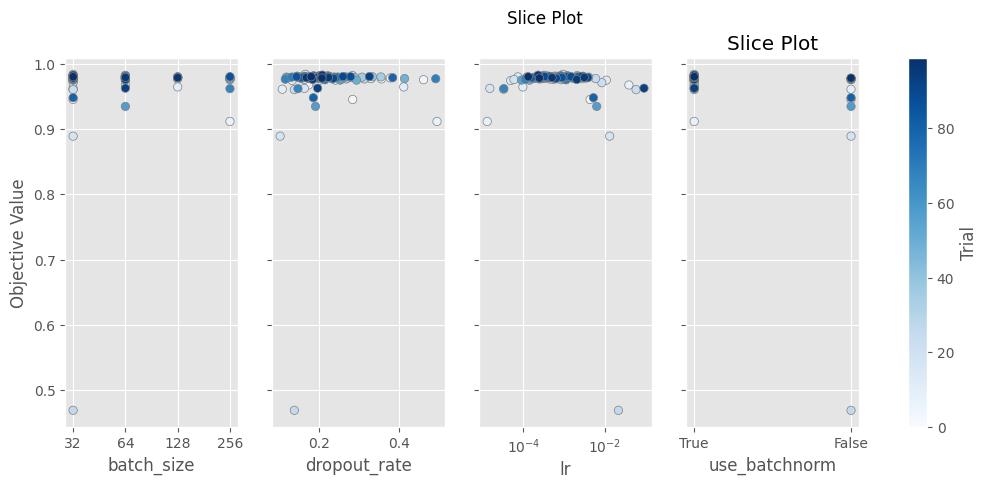

In [22]:
# 4. Parameter value distribution plot
plt.figure(figsize=(10, 6))
optuna.visualization.matplotlib.plot_slice(study)
plt.title("Slice Plot")
plt.show()

In [23]:
# 5. Interactive optimization plot
fig = optuna.visualization.plot_optimization_history(study)
fig.show()

In [24]:
# 6. Interactive parameter importance plot
fig = optuna.visualization.plot_param_importances(study)
fig.show()

In [25]:
# 7. Interactive interaction of parameters plot
fig = optuna.visualization.plot_parallel_coordinate(study)
fig.show()

In [26]:
# 8. Interactive parameter value distribution plot
fig = optuna.visualization.plot_slice(study)
fig.show()